In [13]:
import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parent))

In [3]:

from src.config import raw_data_dir, processed_data_path

In [4]:

data_path = raw_data_dir / "sample_data.npy"
sim = np.load(data_path, allow_pickle=True)

df = pd.DataFrame(sim)

In [5]:
df.head(10)

,initial_mass,initial_z,star_age,mass,logR,logP,logRho,logT,luminosity,opacity,x_mass_fraction_H,y_mass_fraction_He,z_mass_fraction_metals,eps_nuc,eps_nuc_neu_total,eps_grav_nh,eps_grav,zone,q
0,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,1.0,1.0
1,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,2.0,1.0
2,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621206,3.0,1.0
3,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621205,4.0,1.0
4,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632306,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621205,5.0,1.0
5,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632307,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621203,6.0,1.0
6,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632307,-8.726443,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739978e-29,-0.003933,-2.621202,7.0,1.0
7,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632307,-8.726442,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739979e-29,-0.003933,-2.621199,8.0,1.0
8,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632307,-8.726442,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739979e-29,-0.003933,-2.621196,9.0,1.0
9,16.5,0.02,1.124803e+07,15.672543,2.769037,2.632308,-8.726442,3.565941,56927.325018,0.001937,0.667269,0.319678,0.013054,0.042915,1.739980e-29,-0.003933,-2.621193,10.0,1.0


In [9]:
importlib.reload(sys.modules["src.preprocessing"])
from src.preprocessing import check_missing_values, drop_constant_columns, fit_preprocess_scalers, rdp

missing_summary = check_missing_values(df)
print("Missing Values Summary:\n", missing_summary)

epsilon_value = 0.05 
df_rdp = rdp(df, epsilon=epsilon_value)
print(f"Data shape after RDP vs original shape: {df_rdp.shape} vs {df.shape}")

df_reduced = drop_constant_columns(df_rdp)

df_scaled, scalers = fit_preprocess_scalers(
    df_reduced,
    normalize=True,
    standardize=False,
)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, df_scaled.to_numpy())
print(f"Saved processed dataset to {processed_data_path}")

Missing Values Summary:
 Empty DataFrame
Columns: [missing_values, null_percent]
Index: []
Dropping constant columns: ['initial_mass', 'initial_z']
Data shape after RDP vs original shape: (582166, 17) vs (724120, 19)
Saved processed dataset to /work/nvme/bhvr/cadence/Stars_VAE/data/processed/processed_data.npy


In [10]:
df_scaled.head(10)

,star_age,mass,logR,logP,logRho,logT,luminosity,opacity,x_mass_fraction_H,y_mass_fraction_He,z_mass_fraction_metals,eps_nuc,eps_nuc_neu_total,eps_grav_nh,eps_grav,zone,q
0,0.930052,0.949972,0.979358,0.065433,0.143207,0.003962,0.572842,0.000007,0.928648,0.32379,0.000348,5.971173e-08,4.132018e-34,0.406410,0.605472,0.000000,1.000000
1,0.930052,0.949972,0.979358,0.065466,0.143245,0.003978,0.572842,0.000008,0.928648,0.32379,0.000348,5.971173e-08,4.135094e-34,0.406410,0.605472,0.006569,1.000000
2,0.930052,0.949969,0.979354,0.065836,0.143659,0.004154,0.572842,0.000008,0.928648,0.32379,0.000348,5.971173e-08,4.169560e-34,0.406410,0.605472,0.008062,0.999997
3,0.930052,0.949967,0.979351,0.066248,0.144119,0.004357,0.572842,0.000009,0.928648,0.32379,0.000348,5.971173e-08,4.208395e-34,0.406410,0.605472,0.008361,0.999995
4,0.930052,0.949951,0.979328,0.068022,0.146068,0.005316,0.572842,0.000011,0.928648,0.32379,0.000348,5.971173e-08,4.379659e-34,0.406410,0.605472,0.008958,0.999978
5,0.930052,0.949875,0.979237,0.074804,0.152978,0.010550,0.572842,0.000027,0.928648,0.32379,0.000348,5.971173e-08,5.085414e-34,0.406410,0.605472,0.010451,0.999898
6,0.930052,0.949838,0.979198,0.077245,0.155231,0.013112,0.572842,0.000033,0.928648,0.32379,0.000348,5.971173e-08,5.353193e-34,0.406410,0.605472,0.011048,0.999858
7,0.930052,0.949800,0.979161,0.079394,0.157135,0.015602,0.572842,0.000037,0.928648,0.32379,0.000348,5.971173e-08,5.595709e-34,0.406410,0.605472,0.011645,0.999819
8,0.930052,0.949673,0.979054,0.086037,0.162822,0.023926,0.572842,0.000047,0.928648,0.32379,0.000348,5.971173e-08,6.419524e-34,0.406411,0.605472,0.013735,0.999686
9,0.930052,0.949599,0.978998,0.089025,0.165351,0.027939,0.572842,0.000057,0.928648,0.32379,0.000348,5.971173e-08,6.839255e-34,0.406410,0.605472,0.014631,0.999607


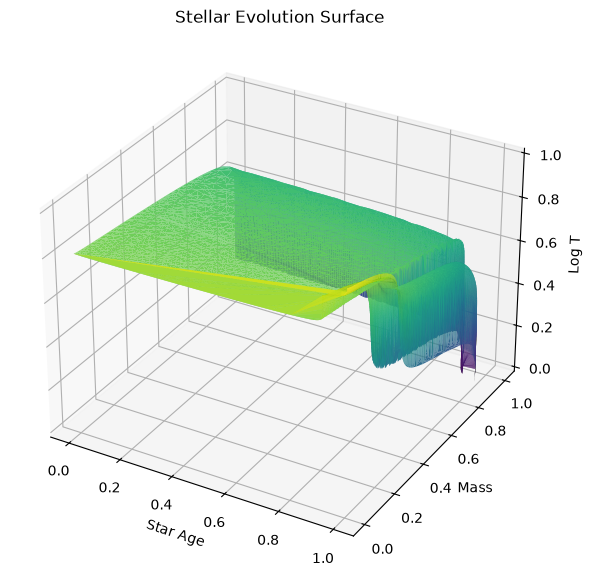

In [11]:
time = df_scaled['star_age'].to_numpy()[::10]
mass = df_scaled['mass'].to_numpy()[::10]
temp = df_scaled['logT'].to_numpy()[::10]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')

ax.plot_trisurf(time, mass, temp, cmap='viridis', edgecolor='none')
ax.set_xlabel('Star Age')
ax.set_ylabel('Mass')
ax.set_zlabel('Log T')
ax.set_title('Stellar Evolution Surface')
plt.show()

In [12]:
fig = go.Figure(
    data=[
        go.Mesh3d(
            x=time,
            y=mass,
            z=temp,
            intensity=temp,
            colorscale="Viridis",
            opacity=0.8,
        )
    ]
)
fig.update_layout(
    scene=dict(
        xaxis_title="Star Age",
        yaxis_title="Mass",
        zaxis_title="Log T",
    ),
    title="Stellar Evolution Surface",
)
fig.show()